# **[W1] Pilot Task**



## **(TASK1) 데이터 출처 표기 및 데이터 불러오기**

**<데이터 개요>**
- 사용 데이터: **Kaggle: Predict Customer Churn**

- URL: https://www.kaggle.com/competitions/playground-series-s6e3/overview

- 목표: 고객 이탈 가능성 예측

- 평가 지표: ROC

---

**<데이터 구성>**
- train.csv: 학습용 데이터, 594,194행
- test.csv: 평가용 데이터, 254,651행
- sample_submission.csv: 제출 예시.(본 분석에서는 필요하지 않음)

In [5]:
# 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Kaggle setting
from google.colab import userdata
import os
import kagglehub

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

path = kagglehub.competition_download('playground-series-s6e3')

print("Path to dataset files", path)

print("Files in path:", os.listdir(path))


In [ ]:
# (기본) 데이터 불러오기
train = pd.read_csv(path + '/train.csv')
test = pd.read_csv(path + '/test.csv')
submission = pd.read_csv(path + '/sample_submission.csv')

In [7]:
# (부가) 데이터 불러오기
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

## **(TASK2) 기초 통계 확인**

**<기초 통계>**
- 데이터 규모: train (594194, 21) | test(254655, 20)
- 결측치: 없음(0건)
- 데이터 특징: float64(2), int64(3), object(16)

---
**<변수 설명>**
1. 고객 기본 정보
- `id`: 고객 식별 번호
- `gender`: 성별 (Male, Female)
- `SeniorCitizen`: 고령자 여부 (1: 고령자, 0: 일반)
- `Partner`: 배우자(파트너) 여부 (Yes, No)
- `Dependents`: 부양가족(자녀, 부모 등) 여부 (Yes, No)

2.서비스 가입 현황

- `tenure`: 서비스 이용한 기간 (개월 수)
- `PhoneService`: 전화 서비스 사용 여부 (Yes, No)
- `MultipleLines`: 다회선 사용 여부 (Yes, No, No phone service)
- `InternetService`: 인터넷 서비스 제공업체 종류 (DSL, Fiber optic, No)
- `OnlineSecurity`: 온라인 보안 서비스 사용 여부 (Yes, No, No internet service)
- `OnlineBackup`: 온라인 백업 서비스 사용 여부 (Yes, No, No internet service)
- `DeviceProtection`: 기기 보호 서비스 사용 여부 (Yes, No, No internet service)
- `TechSupport`: 기술 지원 서비스 사용 여부 (Yes, No, No internet service)
- `StreamingTV`: TV 스트리밍 서비스 사용 여부 (Yes, No, No internet service)
- `StreamingMovies`: 영화 스트리밍 서비스 사용 여부 (Yes, No, No internet service)

3. 계약 및 결제 정보

- `Contract`: 계약 형태 (Month-to-month: 월 단위, One year: 1년, Two year: 2년)
- `PaperlessBilling`: 종이 없는 청구서(전자 청구서) 사용 여부 (Yes, No)
- `PaymentMethod`: 결제 수단(Electronic check: 인라인 코드(전자 수표)| Mailed check: 우편 수표 | Bank transfer(automatic): 자동 은행 이체 | Credit card (automatic): 자동 신용카드 결제)
- `MonthlyCharges`: 매달 청구되는 금액
- `TotalCharges`: 현재까지 청구된 총 금액

4. 타겟 변수 (Target Variable)
- `Churn`: 고객의 이탈 여부 (Yes: 이탈함, No: 유지 중) - 분석의 핵심 목표 변수입니다.

In [9]:
# 데이터 형태
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [10]:
# 데이터 규모
print(f"train: {train.shape}")
print(f"test: {test.shape}")

train: (186429, 21)
test: (213559, 20)


In [11]:
# 결측지 확인
print(f"train: {train.isnull().sum()}\n")
print(f"test: {test.isnull().sum()}")

train: id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            1
PaperlessBilling    1
PaymentMethod       1
MonthlyCharges      1
TotalCharges        1
Churn               1
dtype: int64

test: id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              1
PhoneService        1
MultipleLines       1
InternetService     1
OnlineSecurity      1
OnlineBackup        1
DeviceProtection    1
TechSupport         1
StreamingTV         1
StreamingMovies     1
Contract            1
PaperlessBilling    1
PaymentMethod       1
MonthlyCharges      1
TotalCharges        1
dtype: int64


In [12]:
# 데이터 특징
print(f"train: {train.info()}\n")
print(f"test: {test.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186429 entries, 0 to 186428
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                186429 non-null  int64  
 1   gender            186429 non-null  object 
 2   SeniorCitizen     186429 non-null  int64  
 3   Partner           186429 non-null  object 
 4   Dependents        186429 non-null  object 
 5   tenure            186429 non-null  int64  
 6   PhoneService      186429 non-null  object 
 7   MultipleLines     186429 non-null  object 
 8   InternetService   186429 non-null  object 
 9   OnlineSecurity    186429 non-null  object 
 10  OnlineBackup      186429 non-null  object 
 11  DeviceProtection  186429 non-null  object 
 12  TechSupport       186429 non-null  object 
 13  StreamingTV       186429 non-null  object 
 14  StreamingMovies   186429 non-null  object 
 15  Contract          186428 non-null  object 
 16  PaperlessBilling  18

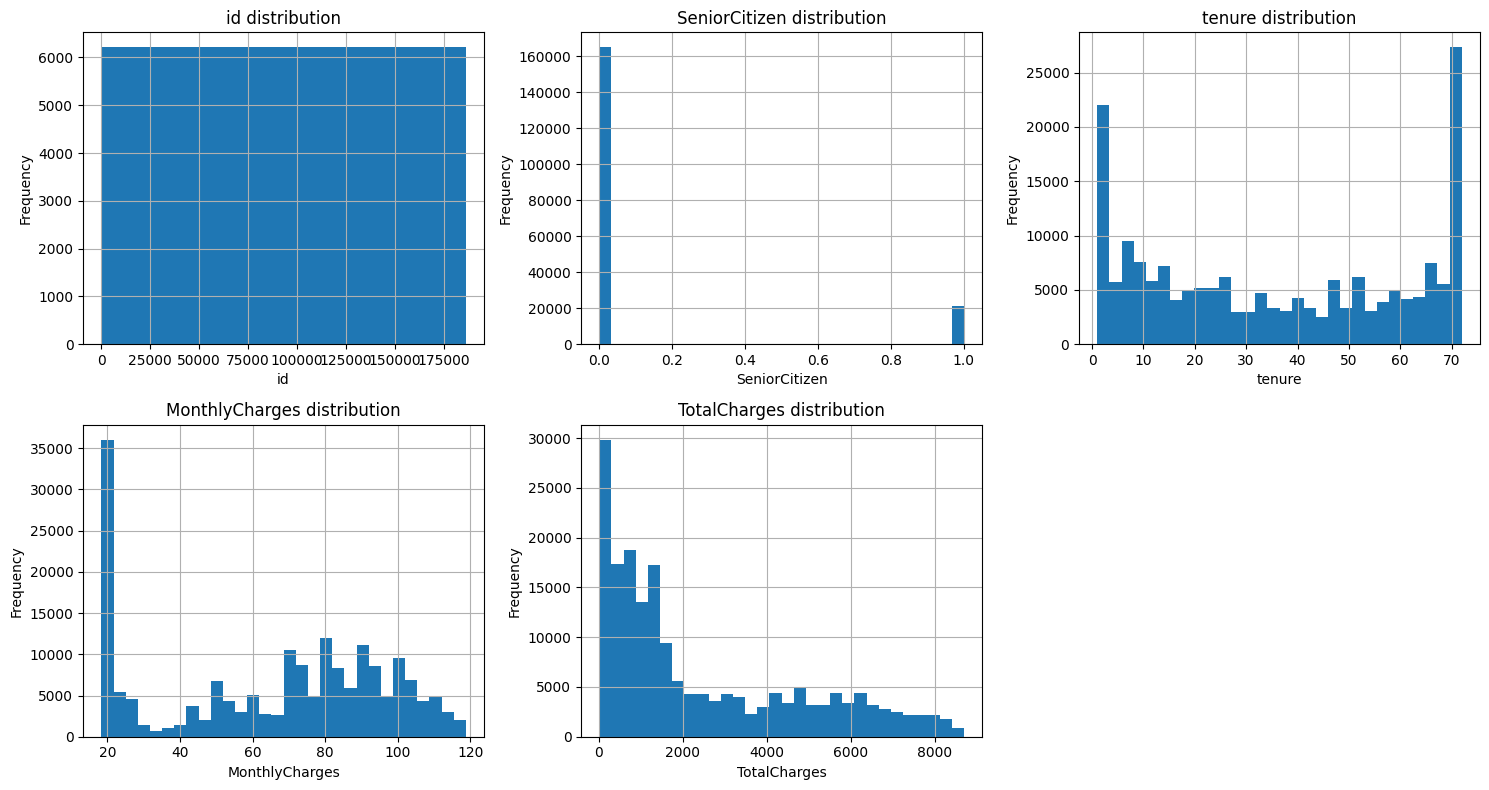

In [13]:
# 데이터 분포 확인(숫자형)
numerical_cols = train.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Histogram.
for i, column in enumerate(numerical_cols):
    if i < len(axes):
        train[column].hist(ax=axes[i], bins=30)
        axes[i].set_title(f"{column} distribution")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

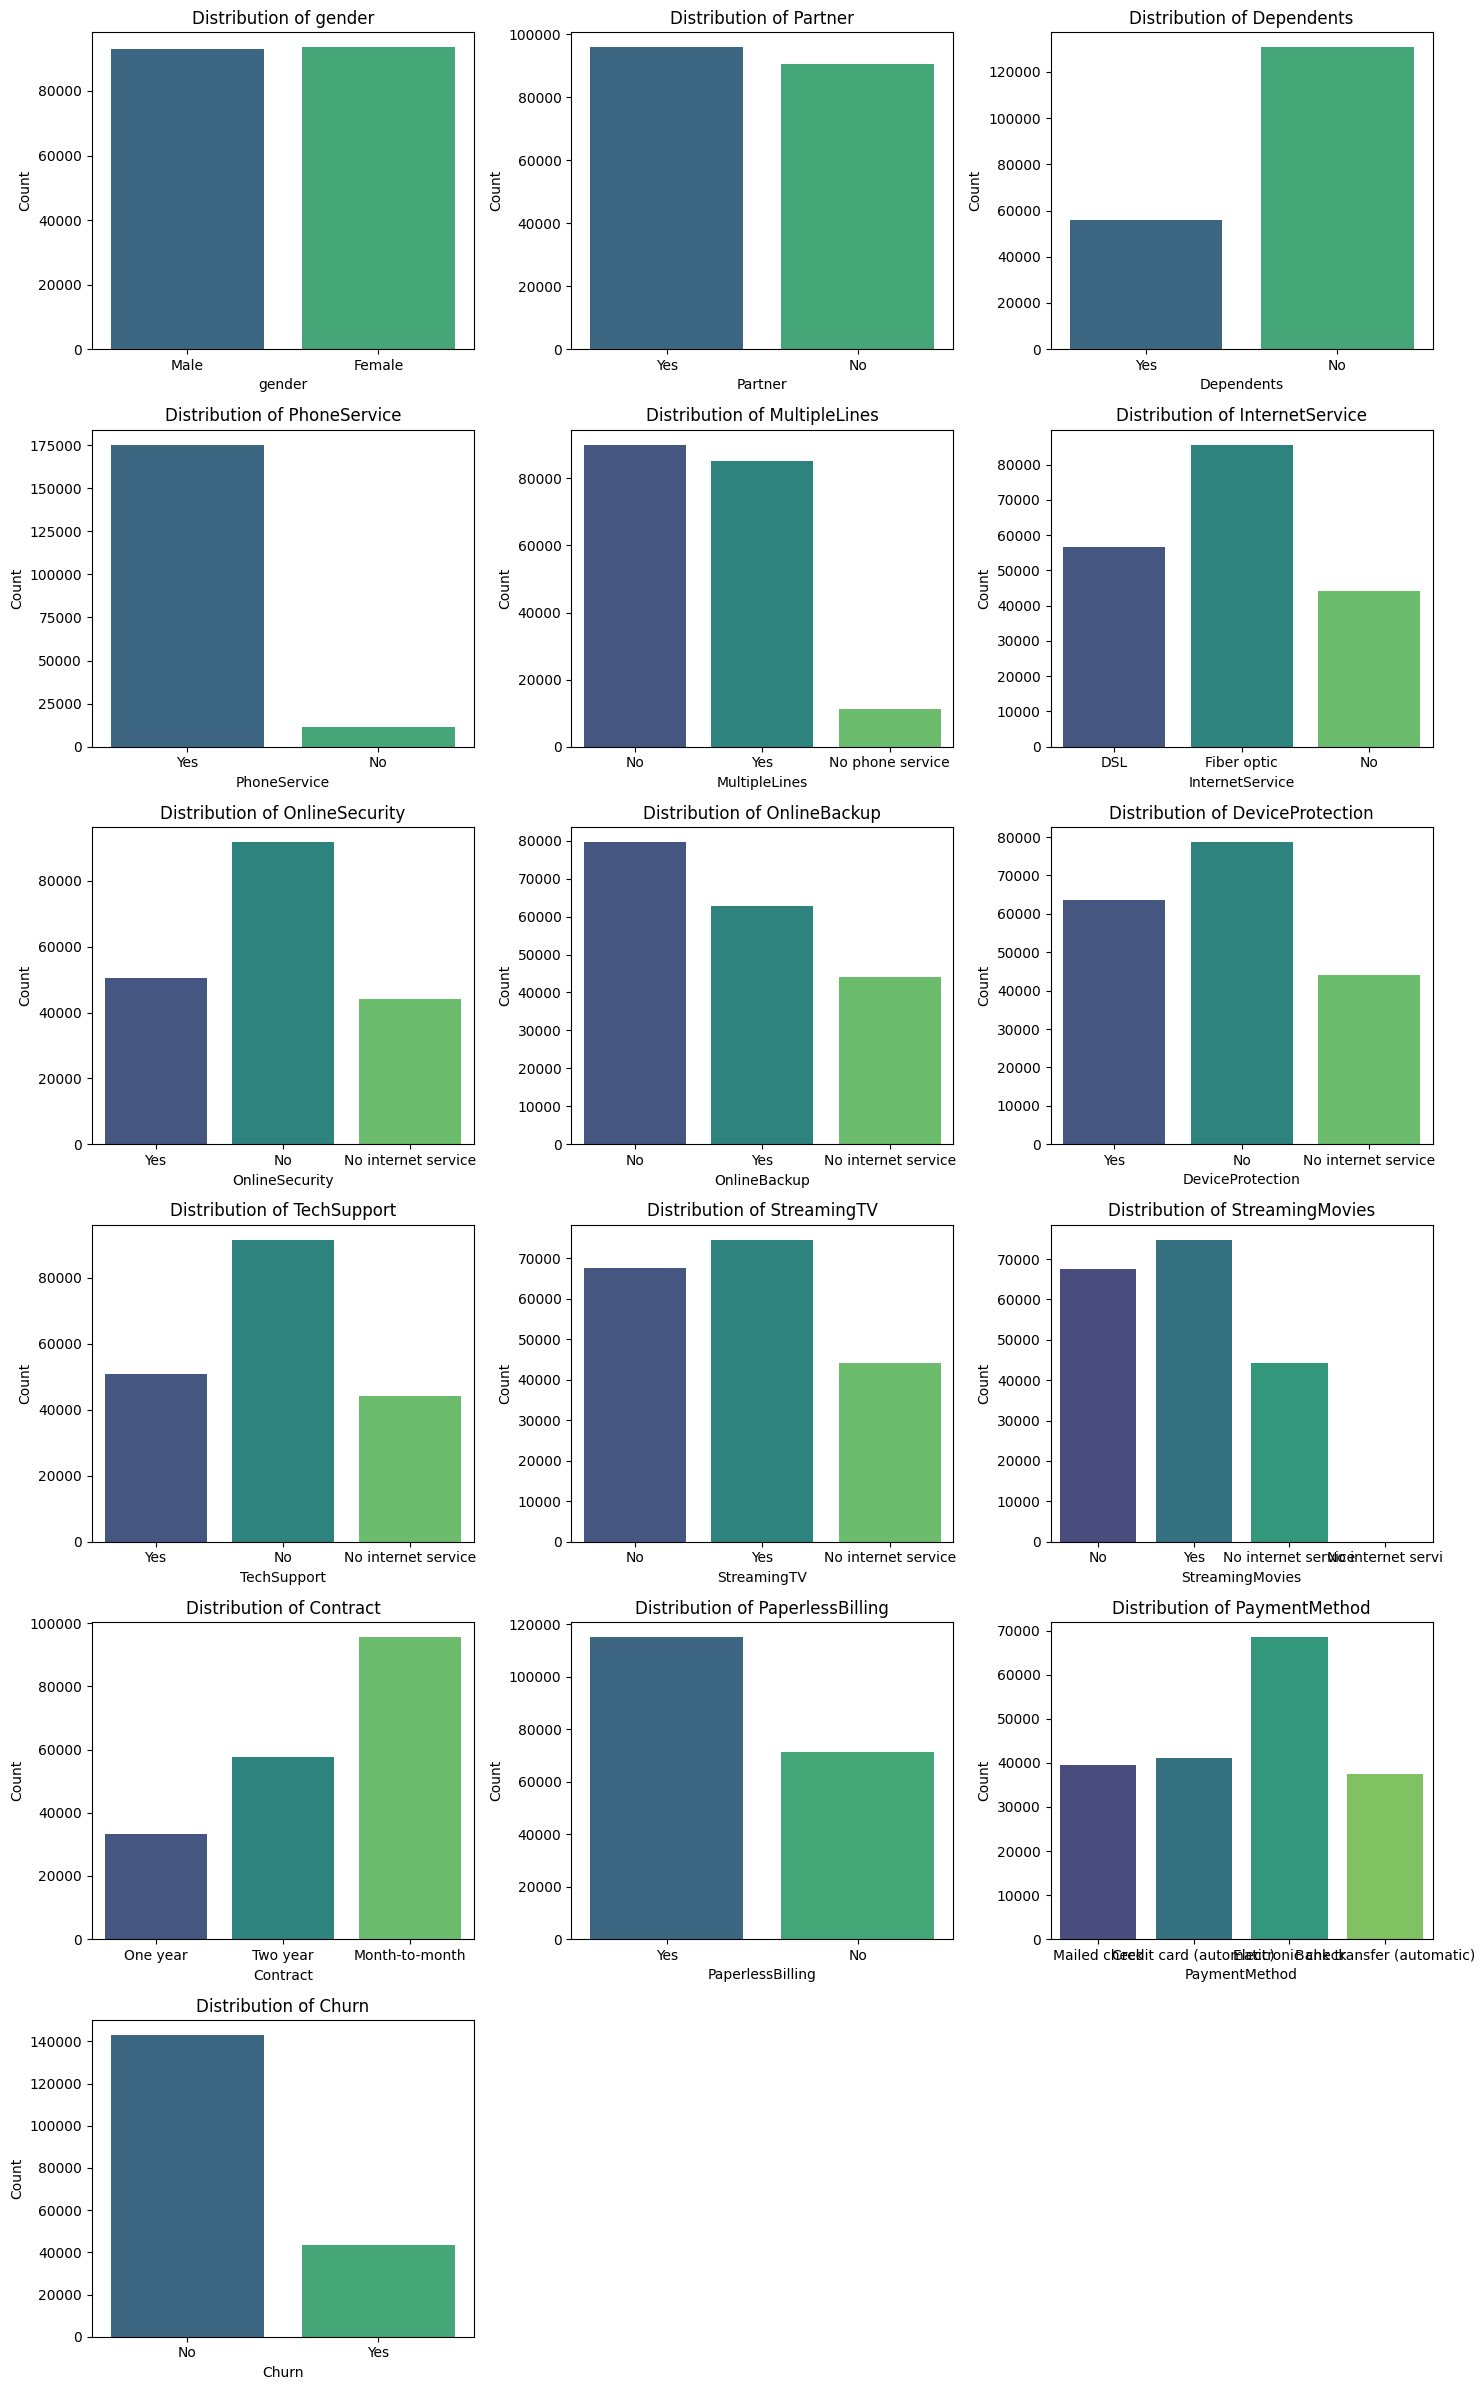

In [15]:
# 데이터 분포 확인(범주형)
categorical_cols = train.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Countplot
for i, column in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(x=column, data=train, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Count')
        if len(train[column].unique()) > 5:
            axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **(TASK3) 분석 목적 및 인사이트 설명**
- 분석 목적: 통신사 고객 이탈 여부(`churn`)에 영향을 미치는 주요 요인을 파악하고, 이를 기반으로 고객 유지를 위한 인사이트를 도출

- 기대 인사이트
    - 어떤 계약 형태(`Contract`)가 고객 유지에 유리한가?
    - 가입 기간(`Tenure`)과 이탈률 사이에는 어떤 상관관계가 있는가
    - 월 요금의 수준(`MonthlyCharges`)이 고객 이탈의 결정적 요인인가?

## **(TASK4) EDA**

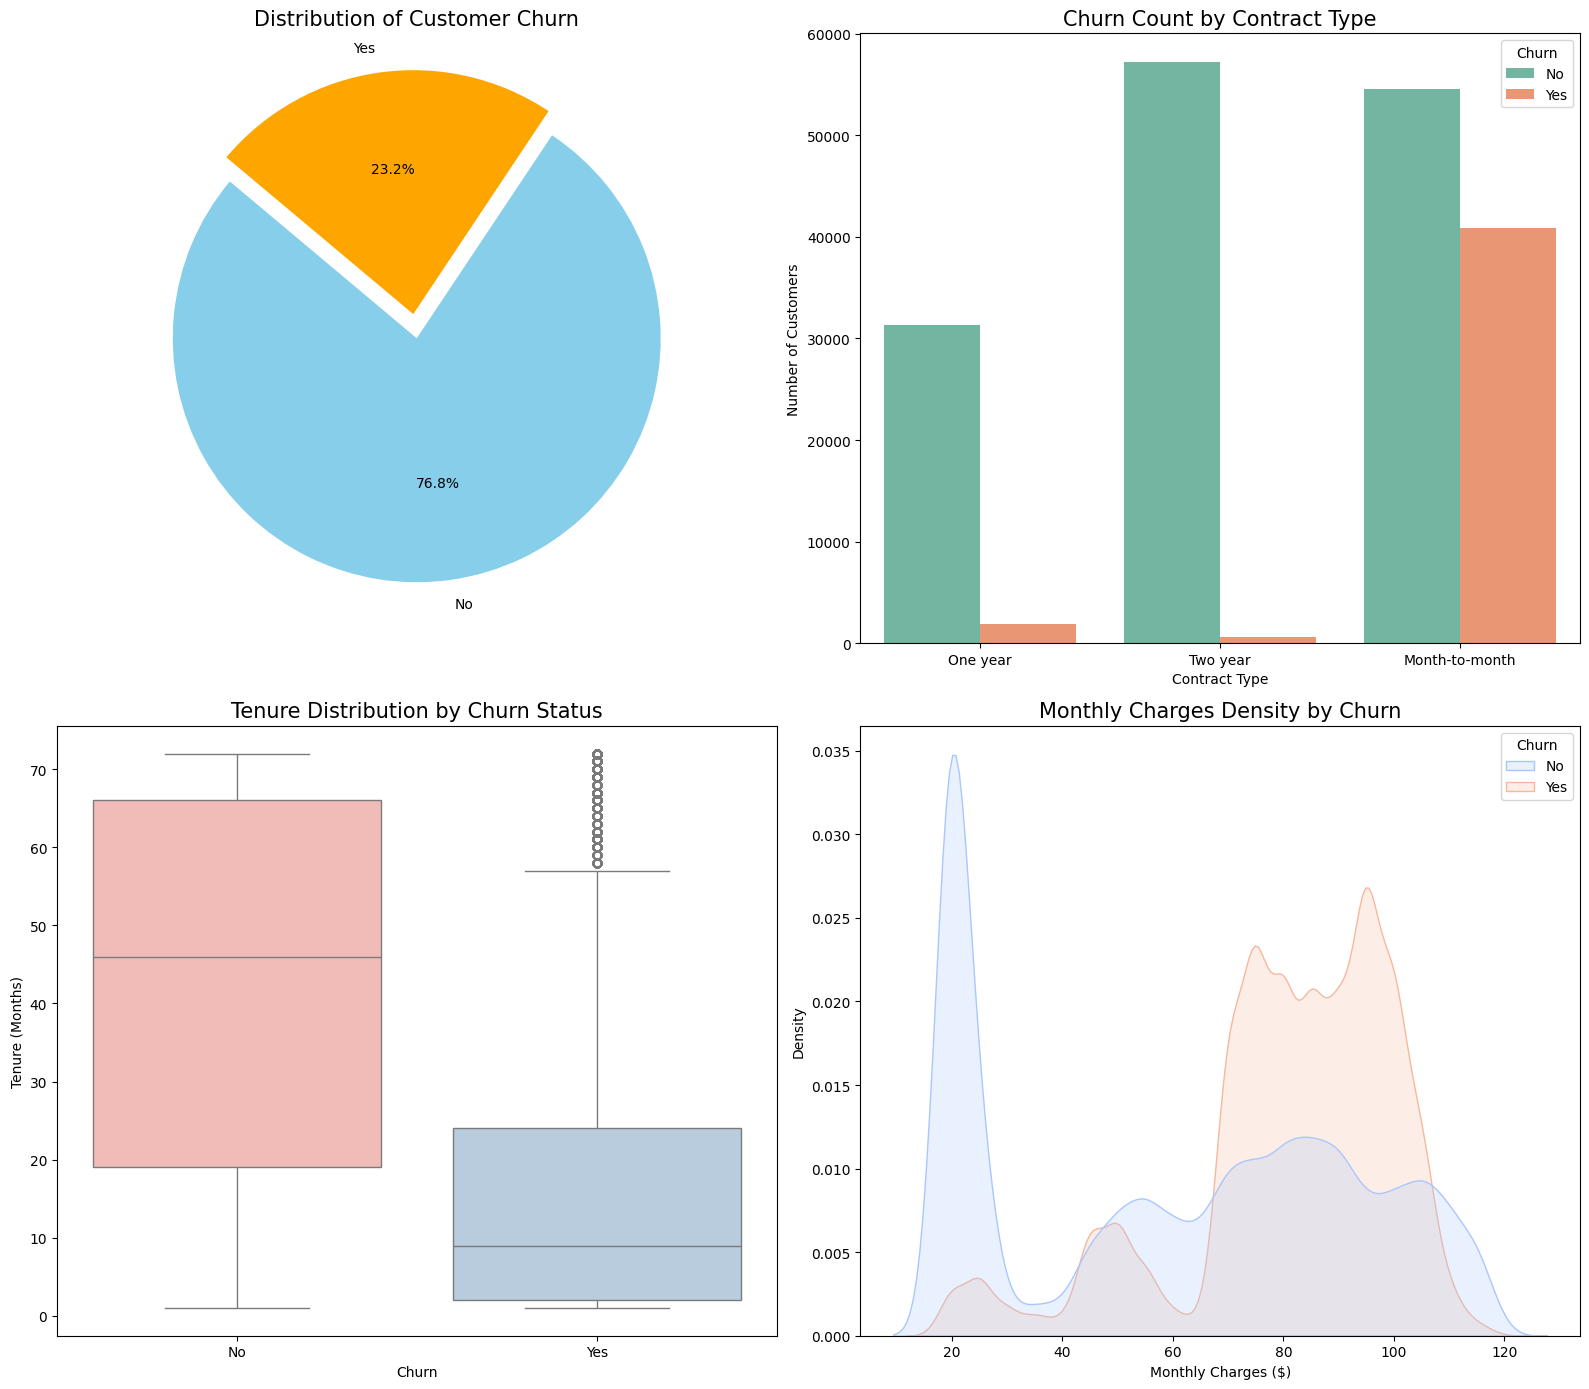

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# [Plot 1] 이탈 여부 비율 (Pie Chart)
churn_counts = train['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
                startangle=140, colors=['skyblue', 'orange'], explode=[0, 0.1])
axes[0, 0].set_title('Distribution of Customer Churn', fontsize=15)

# [Plot 2] 계약 형태와 이탈 관계 (Count Plot)
sns.countplot(data=train, x='Contract', hue='Churn', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Churn Count by Contract Type', fontsize=15)
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Number of Customers')

# [Plot 3] 가입 기간과 이탈 관계 (Box Plot)
sns.boxplot(data=train, x='Churn', y='tenure', palette='Pastel1', ax=axes[1, 0])
axes[1, 0].set_title('Tenure Distribution by Churn Status', fontsize=15)
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Tenure (Months)')

# [Plot 4] 월 요금과 이탈의 밀도 분석 (KDE Plot)
sns.kdeplot(data=train, x='MonthlyCharges', hue='Churn', fill=True,
            common_norm=False, palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges Density by Churn', fontsize=15)
axes[1, 1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

**[Plot 1] Distribution of Customer Churn**
- 전체 고객 중 이탈한 고객(Yes)과 유지 중인 고객(No)의 비율을 나타냄
- 결과: Yes(약 25.5%), No(약 75.5%)
- 해석: 전체 고객 중 이탈 고객이 1/4를 차지하고 있음. 비즈니스 수익에 영향이 있을 것임.

**[Plot 2] Distribution of Customer Churn**
- 계약 형태(월별, 1년, 2년)에 따라 이탈자가 얼마나 발생하는지를 나타냄
- 결과: 월별(Month-to-month)에서 이탈자가 가장 많이 나타남. 반대로 장기 계약일수록 이탈자가 급격히 줄어듦
- 해석: 계약기간은 이탈의 핵심 요인이라고 볼 수 있음. 고객을 오랫동안 유치하는 것이 중요하다고 볼 수 있음

**[Plot 3] Tenure Distribution by Churn Status**
- 이탈 여부에 따른 가입 기간의 분포
- 결과: 이탈한 고객(Yes)의 경우 대개 가입한지 오래되지 않은 신규 고객이 많음. 반면, 지속적으로 이용하는 고객(No)의 경우 상자 분포가 위로 길게 뻗어 있음
- 해석: 가입 초기 단계에서 적응을 하지 못하는 경우 장기 고객으로 전환이 잘 되지 않음

**[Plot 4] Monthly Charges Density by Churn**
- 월 요금(Monthly Charges)의 액수에 따라 이탈자와 유지자의 밀집도 차이
- 결과:
    - 저가 구간(20$ 내외): 유지 고객(No, 파란색)의 밀도가 높음
    
    - 고가 구간(70~100$): 이탈 고객(Yes, 주황색)의 분포가 유지 고객보다 더욱 밀집되어 있음
- 해석: 비싼 요금이 초기 고객에게 이탈 요인으로 작용할 수 있음.

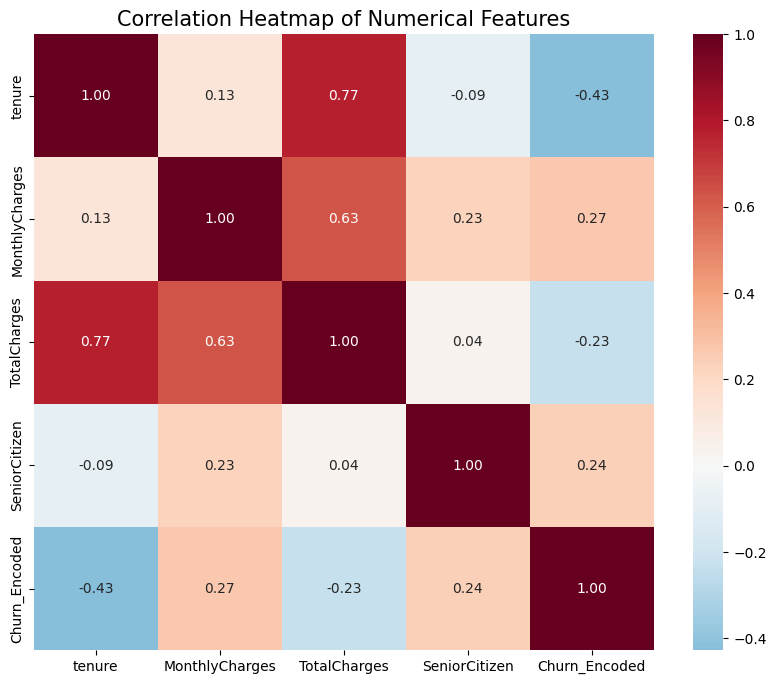

In [22]:
# [Plot 5] 상관관계 히트맵
train['Churn_Encoded'] = train['Churn'].map({'Yes': 1, 'No': 0})

# 주요 변수 선택 및 상관계수 산출
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Encoded']
corr_matrix = train[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=15)
plt.show()

**[Plot 5] Correlation Heatmap of Numerical Features**
- 주요 상관 관계: tenure-TotalCharges(0.77) | Monthlycharges-TotalCharges(0.66) | **tenure-Churn_Encoded(-0.43)**
- 결과:
    - tenure-Churn_Encoded(-0.43): 가입기간이 늘어날수록 이탈 확률이 낮아짐